In [86]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

# import src.learning_gradient_flow.gradient_flow_optimizer as gradient_flow_optimizer
from learning_gradient_flow import gradient_flow_optimizer, adam_flow_optimizer, sindy_tools

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = 'cpu'
print(f"Using device: {device}")
torch.manual_seed(0)

def get_flattened_parameters(model: nn.Module) -> torch.Tensor:
    params = []
    for p in model.parameters():
        params.append(p.data.clone().view(-1))
    return torch.cat(params)

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )
        # self.layers = nn.Sequential(
        #     nn.Linear(1, 16),
        #     nn.Tanh(),
        #     nn.Linear(16, 16),
        #     nn.Tanh(),
        #     nn.Linear(16, 1)
        # )
    def forward(self, x):
        return self.layers(x)

model = SimpleNet().to(device)

def true_fcn(x):
    return torch.sin(x * np.pi).to(device)

n_data = 500
nl = 0.0
x = 2 * torch.rand(n_data, 1).to(device) - 1
y = true_fcn(x) + nl * torch.randn_like(x)

# print n params
n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params}")

Using device: cpu
Number of parameters: 25


History size: 200
Truncation rank: None
Running optimizers:
 - sgd
 - sindy_weak_thresh0.00000
    SINDy params: SINDyParams(poly_order=2, include_bias=True, truncation_rank=None, method='weak', test_func_params=None, solver_fn=<function stls_sparse_solver at 0x000001814AA5BF60>, solver_params=SparseSolverParams(threshold=0.0, max_iter=20, rcond=None, driver=None, convergence_tol=1e-07, normalize_columns=False))
 - sindy_strong_thresh0.00000
    SINDy params: SINDyParams(poly_order=2, include_bias=True, truncation_rank=None, method='strong', test_func_params=None, solver_fn=<function stls_sparse_solver at 0x000001814AA5BF60>, solver_params=SparseSolverParams(threshold=0.0, max_iter=20, rcond=None, driver=None, convergence_tol=1e-07, normalize_columns=False))
 - sindy_weak_thresh0.00010
    SINDy params: SINDyParams(poly_order=2, include_bias=True, truncation_rank=None, method='weak', test_func_params=None, solver_fn=<function stls_sparse_solver at 0x000001814AA5BF60>, solver_params=Spa

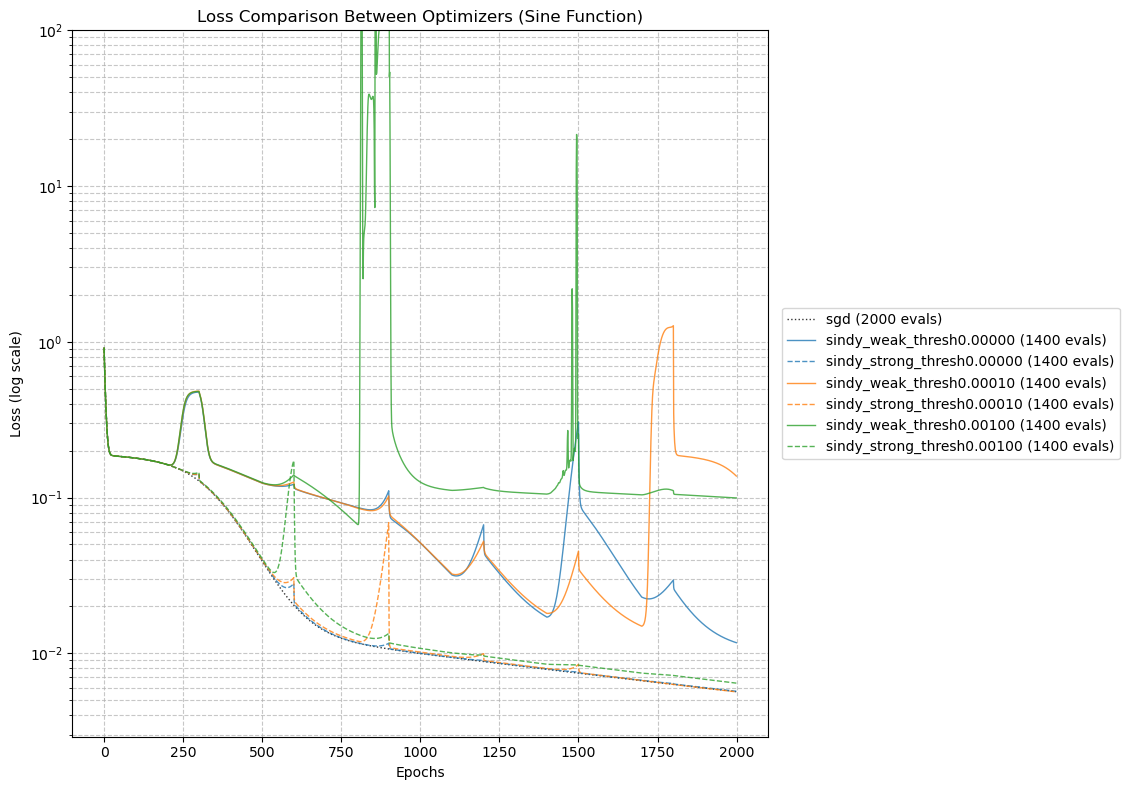

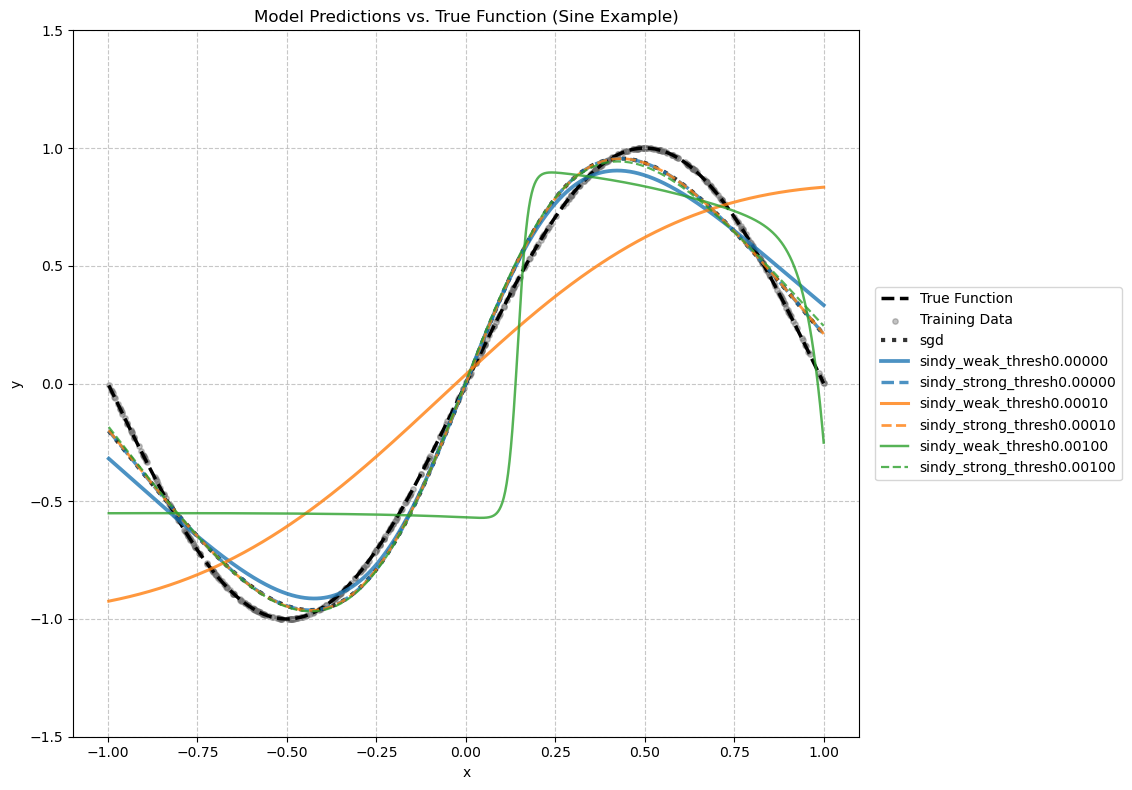

In [89]:
# Training loop
epochs = 2000
batch_size = n_data
# batch_size = n_data // 5
# data loader
train_dataset = torch.utils.data.TensorDataset(x, y)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
n_batches = len(train_loader)

optimizer_names = []
optimizers = {}

lr = 0.1
sgd_model = SimpleNet().to(device)
optimizers['sgd'] = {
    'model': sgd_model,
    'optimizer': torch.optim.SGD(sgd_model.parameters(), lr=lr),
    'losses': [],
    'param_history': []
}
optimizer_names.append('sgd')

# SINDy Optimizers Configuration
# sparsity_thresholds = [0.0]  # Define various thresholds for STLSQ
sparsity_thresholds = [0.0, 1e-4, 1e-3]  # Define various thresholds for STLSQ
normalize_columns_sindy = False              # Unified option for normalize_columns in SINDy solver
# history_size = epochs * n_batches // 10
history_size = 200
truncation_rank = None if n_params < 100 else 20
print(f"History size: {history_size}")
print(f"Truncation rank: {truncation_rank}")
# history_size = 200
# Retrain slightly more often than just filling history, e.g., 1.5 times history_size
# or ensure it's at least a certain number of steps if history_size is small.
retrain_interval = int(history_size * 1.5)

# test_func_params = sindy_tools.TestFunctionParams(width=2, p=5, stride=1)
# test_func_params = None

ode_solver_options = {'rtol': 1e-6, 'atol': 1e-6, 'method': 'rk4', 'options': {'step_size': lr/10}}

for threshold in sparsity_thresholds:
    for method in {'strong', 'weak'}:
        opt_name = f'sindy_{method}_thresh{threshold:.5f}'
        optimizer_names.append(opt_name)

        # Each optimizer gets its own model instance
        model_instance = SimpleNet().to(device)

        # Backup optimizer for SINDyFlow, operating on the same model instance
        backup_optimizer_instance = torch.optim.SGD(
            model_instance.parameters(), lr=lr
        )

        solver_params = sindy_tools.SparseSolverParams(threshold=threshold, normalize_columns=normalize_columns_sindy)
        sindy_params = sindy_tools.SINDyParams(poly_order=2, include_bias=True, truncation_rank=truncation_rank, method=method,
                                        solver_fn=sindy_tools.stls_sparse_solver, solver_params=solver_params)

        optimizers[opt_name] = {
            'model': model_instance,
            'optimizer': gradient_flow_optimizer.SINDyFlow(
                model_instance.parameters(),
                backup_optimizer=backup_optimizer_instance,
                dt=lr,  # Using the same lr as dt for SINDyFlow
                ode_solver_options=ode_solver_options,
                history_size=history_size,
                retrain_interval=retrain_interval,
                sindy_params=sindy_params,
            ),
            'losses': [],
            'param_history': [] # Stores flattened parameters after each epoch
        }

# Print running optimizers
print("Running optimizers:")
for opt_name in optimizer_names:
    print(f" - {opt_name}")
    if 'sindy' in opt_name.lower(): # Check if it's a SINDy optimizer
        # Accessing sindy_kwargs from the instantiated SINDyFlow optimizer
        print(f"    SINDy params: {optimizers[opt_name]['optimizer'].sindy_params}")


# Ensure all models start with the same initial parameters
# Use the parameters of the first model in the list (SGD) as the reference
initial_model_name = optimizer_names[0]
# Deepcopy state_dict if there's any concern about shared references,
# though load_state_dict creates new tensors.
initial_state_dict = optimizers[initial_model_name]['model'].state_dict()

for opt_name, opt_data in optimizers.items():
    if opt_name != initial_model_name:
        opt_data['model'].load_state_dict(initial_state_dict)
    # Record initial parameters for all models
    opt_data['param_history'].append(
        get_flattened_parameters(opt_data['model']) # Shape: (n_params,)
    )


def create_closure(model, optimizer, x_batch_data, y_batch_data):
    def closure():
        optimizer.zero_grad()
        output = model(x_batch_data)
        loss = torch.mean((output - y_batch_data)**2)
        loss.backward()
        return loss
    return closure

# Training loop
for epoch in range(epochs):
    for opt_name, opt_data in optimizers.items():
        model = opt_data['model']
        optimizer = opt_data['optimizer']
        epoch_loss_sum = 0.0

        # Iterate over batches from the DataLoader
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            closure_fn = create_closure(model, optimizer, x_batch, y_batch)

            loss_val = optimizer.step(closure_fn)

            # Ensure loss_val is a Python number (e.g. .item())
            if torch.is_tensor(loss_val):
                loss_val = loss_val.item()
            epoch_loss_sum += loss_val

        opt_data['losses'].append(epoch_loss_sum / n_batches)
        opt_data['param_history'].append(get_flattened_parameters(model))

    if epochs < 20 or epoch % (epochs // 20) == 0 or epoch == epochs - 1:
        status_parts = []
        for name_key, data_val in optimizers.items():
            if data_val['losses']:
                 status_parts.append(f"{name_key}: {data_val['losses'][-1]:.6f}")
            else: # Should not happen if training proceeds normally
                 status_parts.append(f"{name_key}: N/A")
        status_str = ", ".join(status_parts)
        print(f"Epoch {epoch+1}/{epochs}, Avg Loss: {status_str}")


# Get number of function evaluations for legend
for opt_name, opt_data in optimizers.items():
    # Check if optimizer has 'state' and 'func_evals' (common for LBFGS, SINDyFlow)
    if hasattr(opt_data['optimizer'], 'state') and \
       isinstance(opt_data['optimizer'].state, dict):
        func_evals = opt_data['optimizer'].state.get('func_evals', None)
        if func_evals is not None:
            opt_data['func_evals'] = func_evals
        else:
            # Default for optimizers like SGD or if not tracked by SINDyFlow state
            opt_data['func_evals'] = epochs * n_batches
    else:
        # Default for optimizers without state or func_evals tracking (e.g., SGD)
        opt_data['func_evals'] = epochs * n_batches


# let's get a bunch of colors for the plotting style. Use a continuous map based on log(threshold)
# add 'black' as the first, for sgd01
# two will be at this color, but different linestyle
# linestyle will be dots, then solid and dashed alternating
linestyles = ['dotted'] + ['solid', 'dashed'] * (len(sparsity_thresholds))
colors = ['black'] + [f'C{i//2}' for i in range(2*len(sparsity_thresholds))]

# Plot loss curves
plt.figure(figsize=(14, 8)) # Increased figure size for better legend visibility
lw_factor = 1.0 # Initial linewidth factor

for i, (opt_name, opt_data) in enumerate(optimizers.items()):
    # Use .get for func_evals in case it's missing, though it should be set above
    label = f'{opt_name} ({opt_data.get("func_evals", "N/A")} evals)'
    plt.semilogy(
        opt_data['losses'],
        label=label,
        linewidth=max(lw_factor, 0.5), # Ensure minimum linewidth
        color=colors[i],
        alpha=0.8,
        linestyle=linestyles[i]
    )
    # lw_factor *= 0.9 # Slightly decrease linewidth for subsequent plots
plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.title('Loss Comparison Between Optimizers (Sine Function)')
# Adjust legend position to prevent overlap, place outside plot area
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
ylim = plt.ylim() # Get current y-limits
plt.ylim(ylim[0], min(1e2, ylim[1]))
plt.tight_layout(rect=[0, 0, 0.82, 1]) # Adjust layout to make space for legend on the right

# Ensure 'figs' directory exists before saving
import os
if not os.path.exists('figs'):
    os.makedirs('figs')
plt.savefig('figs/sine_loss_comparison_threshold_scan.png', dpi=300, bbox_inches='tight')
plt.show()

# Compare model predictions on evaluation data
# x_eval shape: (1000, 1)
x_eval = torch.linspace(x.min().item(), x.max().item(), 1000).view(-1, 1).to(device)
# y_eval_true shape: (1000, 1)
y_eval_true = true_fcn(x_eval)
y_eval_preds = {} # Stores predictions for each optimizer

for opt_name, opt_data in optimizers.items():
    with torch.no_grad(): # Disable gradient calculations for inference
        # y_eval_preds[opt_name] shape: (1000, 1)
        y_eval_preds[opt_name] = opt_data['model'](x_eval)

plt.figure(figsize=(14, 8)) # Increased figure size
lw_factor = 3.0
# Plot true function
plt.plot(x_eval.cpu(), y_eval_true.cpu(), 'k--', label='True Function', linewidth=2.5)
# Scatter plot of training data
plt.scatter(x.cpu(), y.cpu(), color='dimgray', alpha=0.4, label='Training Data', s=15)

for i, (opt_name, y_eval_pred) in enumerate(y_eval_preds.items()):
    plt.plot(
        x_eval.cpu(), y_eval_pred.cpu(),
        label=opt_name,
        linewidth=max(lw_factor, 0.5),
        alpha=0.8,
        color=colors[i],
        linestyle=linestyles[i]
    )
    lw_factor *= 0.9

plt.title('Model Predictions vs. True Function (Sine Example)')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.ylim(-1.5, 1.5) # Set y-limits for better visibility
plt.tight_layout(rect=[0, 0, 0.82, 1]) # Adjust layout for legend
plt.savefig('figs/sine_model_predictions_threshold_scan.png', dpi=300, bbox_inches='tight')
plt.show()

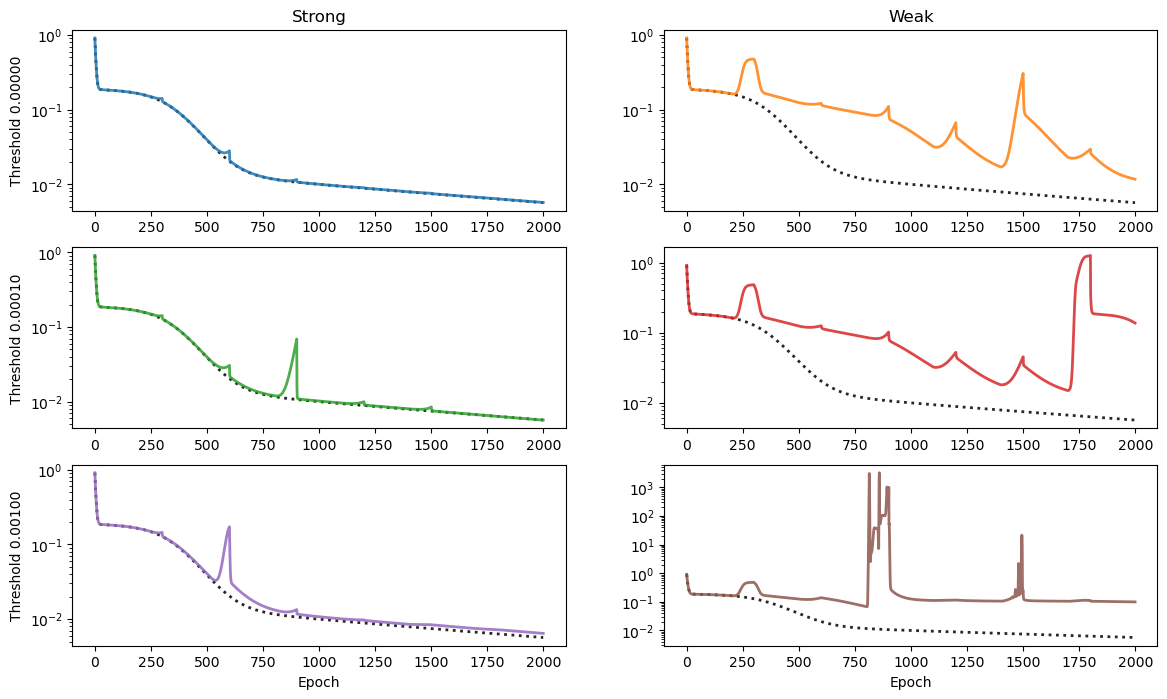

In [90]:
# generate a subplot, where we show the sgd loss in each, but the sindy loss will vary based on threshold and method.
# two columns (methods) and various rows based on threshold

fig, axs = plt.subplots(len(sparsity_thresholds), 2, figsize=(14, 8), squeeze=False)
it = 0
for i, threshold in enumerate(sparsity_thresholds):
    for j in [0, 1]:
        method=['strong', 'weak'][j]
        opt_name = f'sindy_{method}_thresh{threshold:.5f}'
        # Plot SGD loss
        axs[i, j].semilogy(
            optimizers['sgd']['losses'],
            label='SGD',
            linewidth=2.0,
            color='black',
            alpha=0.85,
            linestyle=':'
        )
        # Plot SINDy loss
        axs[i, j].semilogy(
            optimizers[opt_name]['losses'],
            label=opt_name,
            linewidth=2.0,
            color=f'C{it}',
            # color=f'C{i}',
            # linestyle=linestyles[it],
            alpha=0.85,
        )
        it += 1

        if i == 0:
            axs[i, j].set_title(f"{method.capitalize()}")
        elif i == len(sparsity_thresholds) - 1:
            axs[i, j].set_xlabel('Epoch')
        if j == 0:
            axs[i, j].set_ylabel(f"Threshold {threshold:.5f}")

---
# Smaller Model (25 parameters)
---
## Full Batch Comparisons
### 100 Epochs per SINDy Model
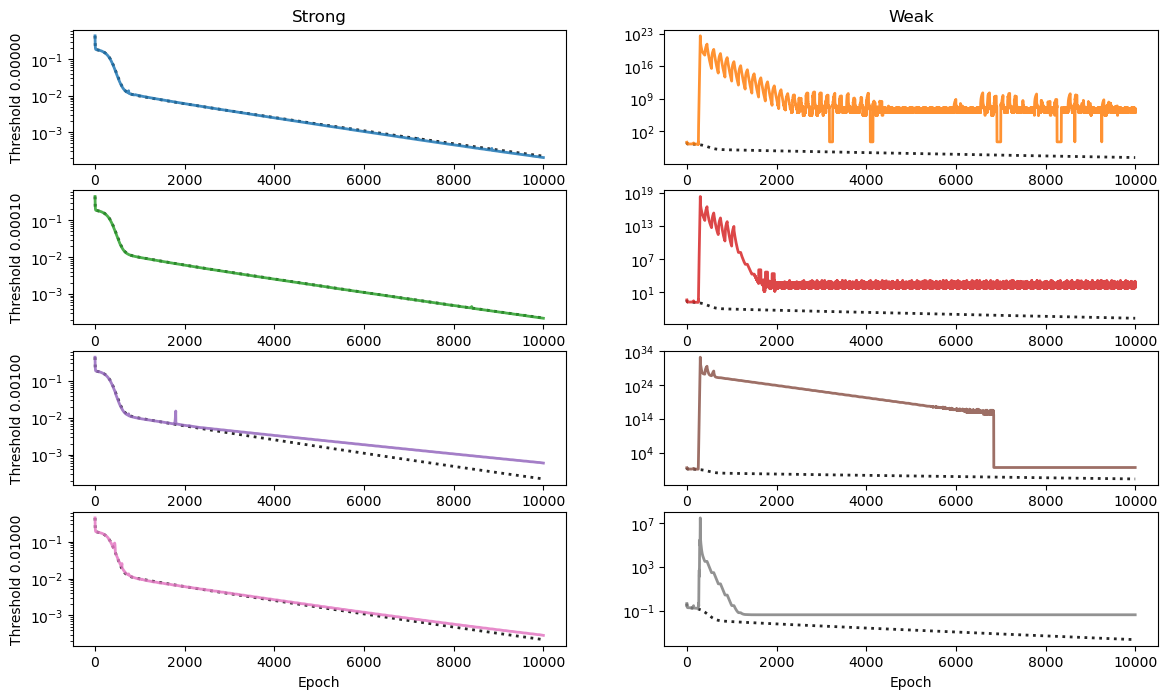

### 200 Epochs per SINDy Model
Just the start, also some minor hyperparameter changes
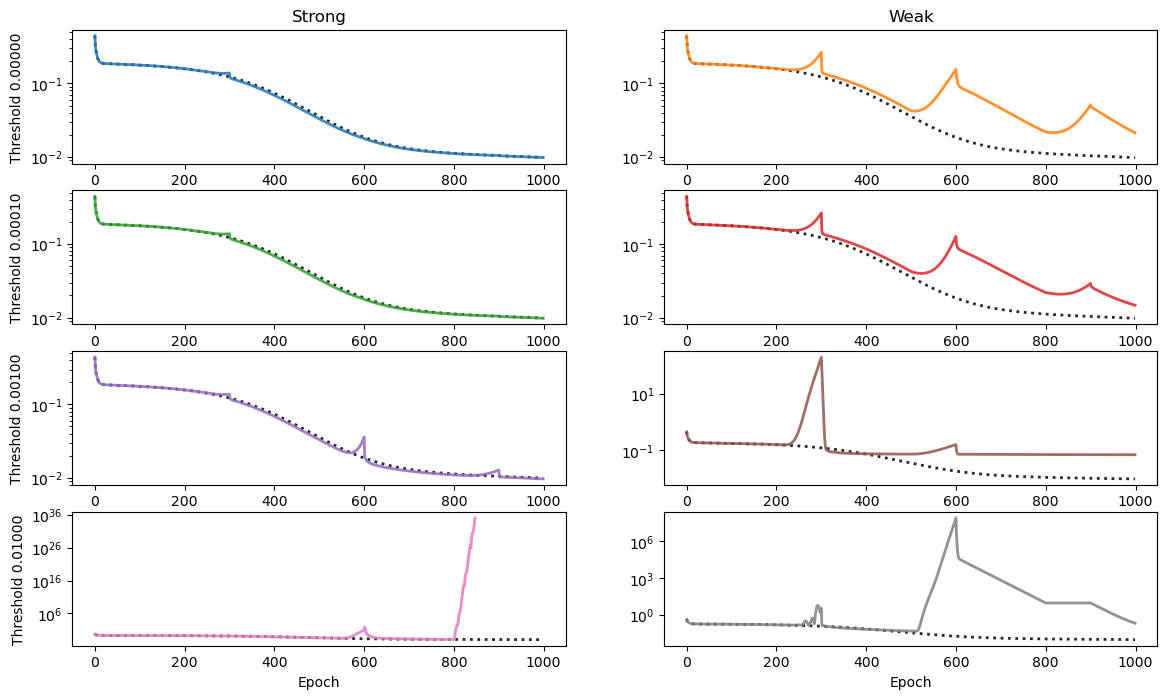

### 400 Epochs per SINDy Model
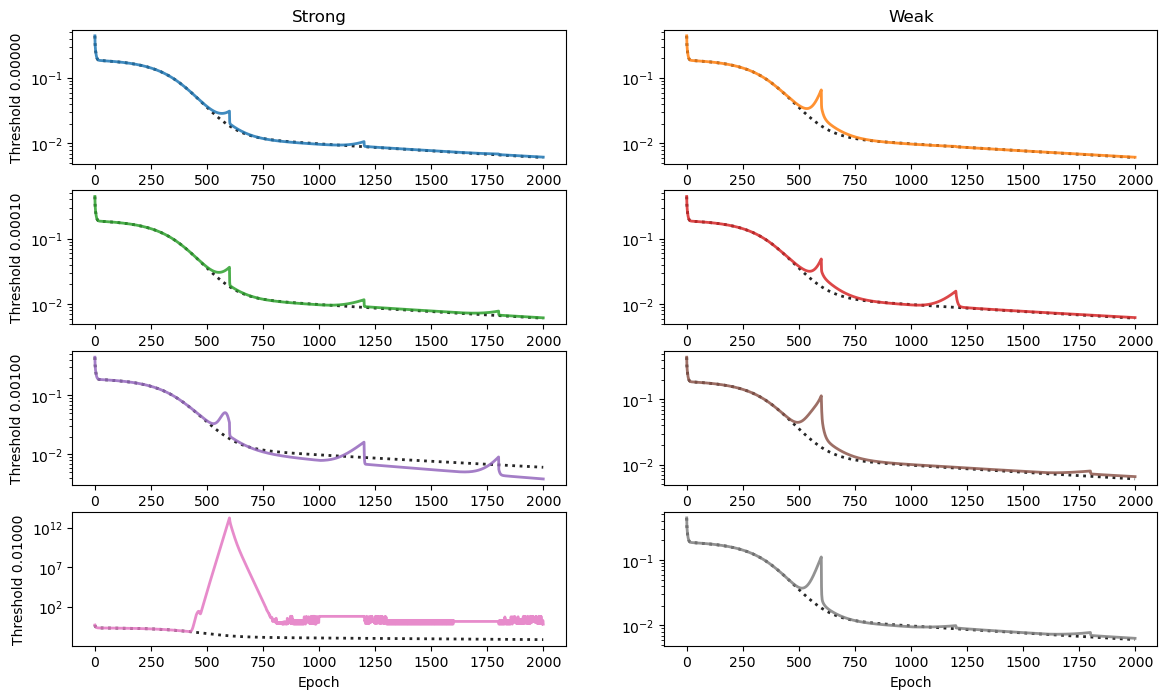

## Minibatch Comparisons
### History size = 500 (batches) with (10 batches per epoch)
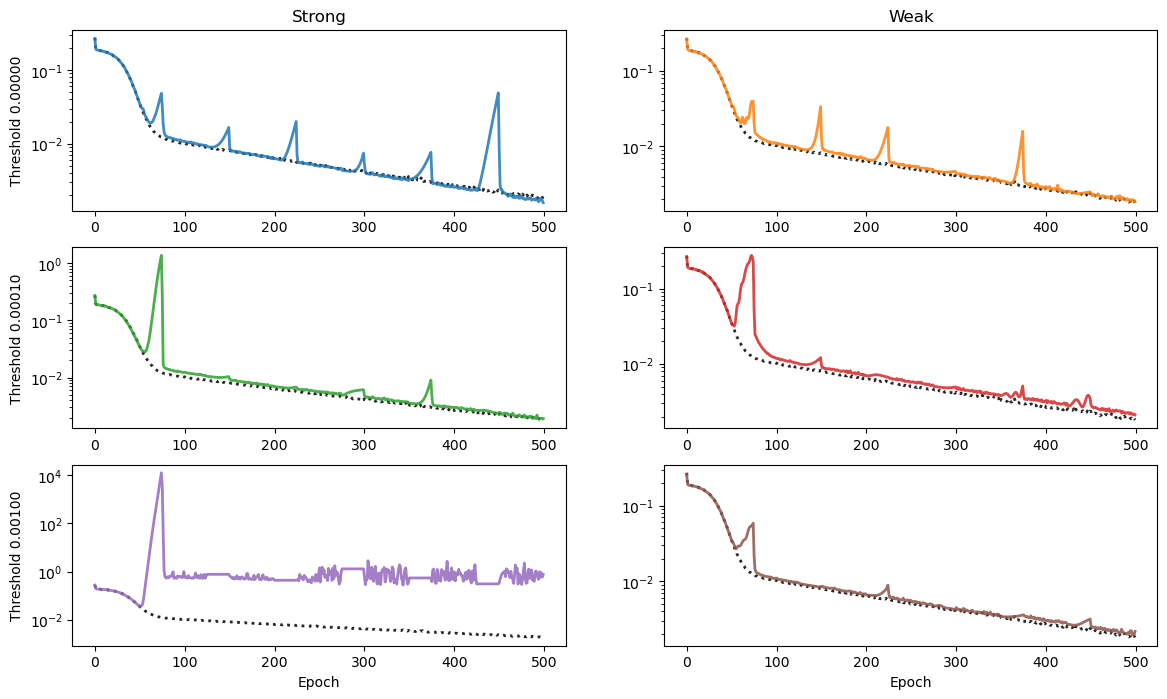

### History size = 500 (batches), but larger batches (5 batches per epoch)
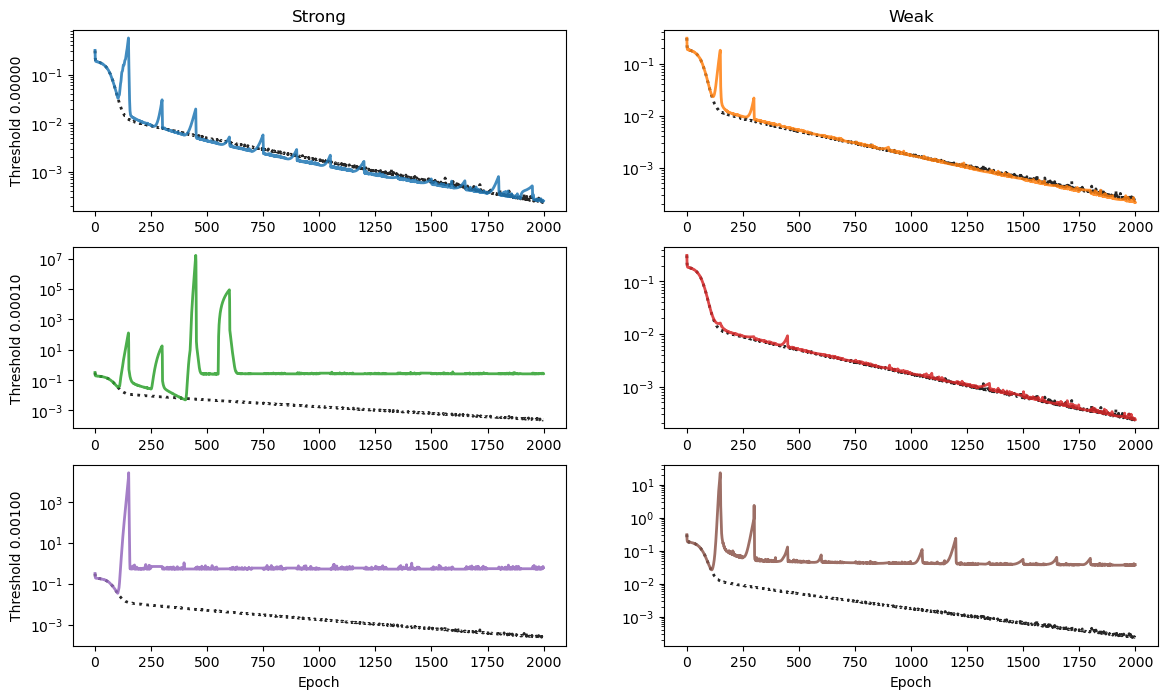

---
# Larger Model (321 parameters)
---

No luck with the thresholding... More susceptible to Nans

Alternatively increase the polynomial order for the other problem

### Truncation rank 10 (and poly order 2)
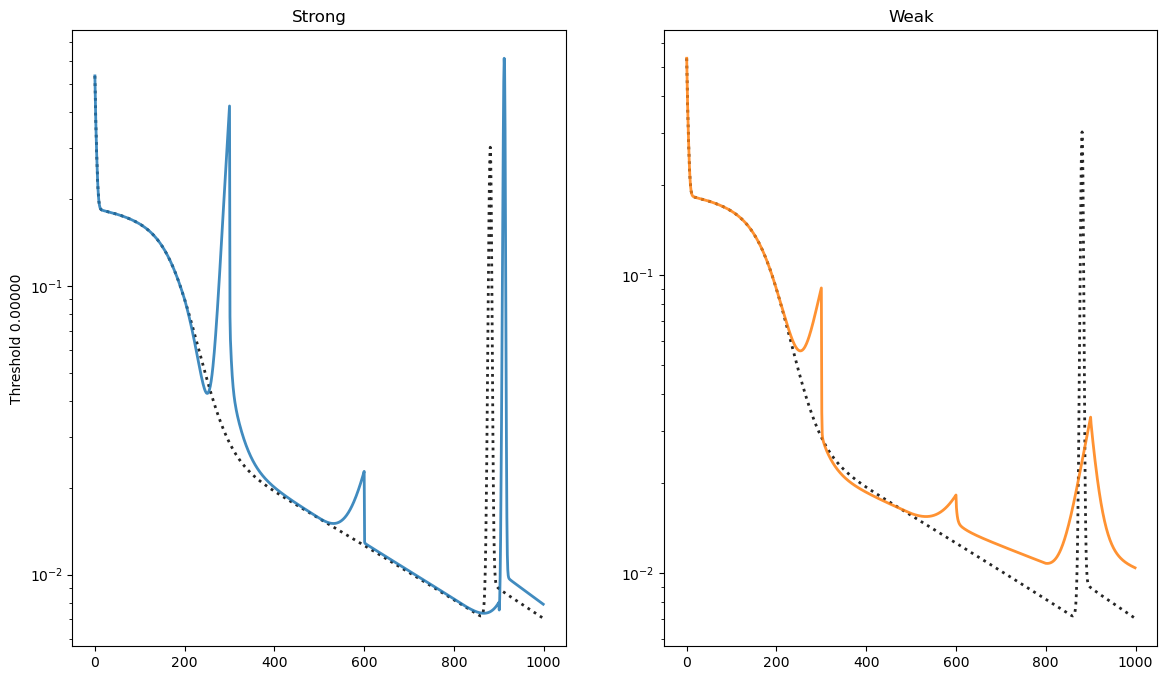